In [1]:
from main.scheduler import EDMScheduler
import matplotlib.pyplot as plt

from omegaconf import OmegaConf
import torch

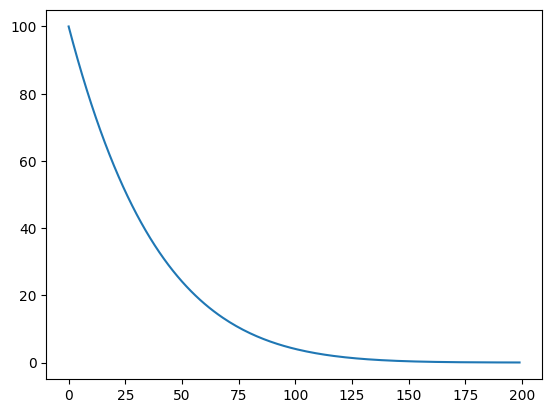

In [2]:
num_steps = 200
edmsampler1 = EDMScheduler(num_steps)
t = edmsampler1.get_discrete_time_steps(num_steps)
sigma = edmsampler1.get_sigma(t)
plt.plot(t)

In [3]:
#Load a model using a config file
from model import get_model
model_config_yaml = 'configs/model/ffhq256ddpm.yaml'
model_config = OmegaConf.load(model_config_yaml)
model = get_model(**model_config)

/home/jovyan/dl_env/dl_env1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#Load a dataset using a config file
from data import get_dataset
dataset_config_yaml = 'configs/data/ffhq.yaml'
dataset_config = OmegaConf.load(dataset_config_yaml)
dataset = get_dataset(**dataset_config)
images = dataset.get_data(5)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9564951..0.9974265].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9917892..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.993505].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.998652..1.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99938726].


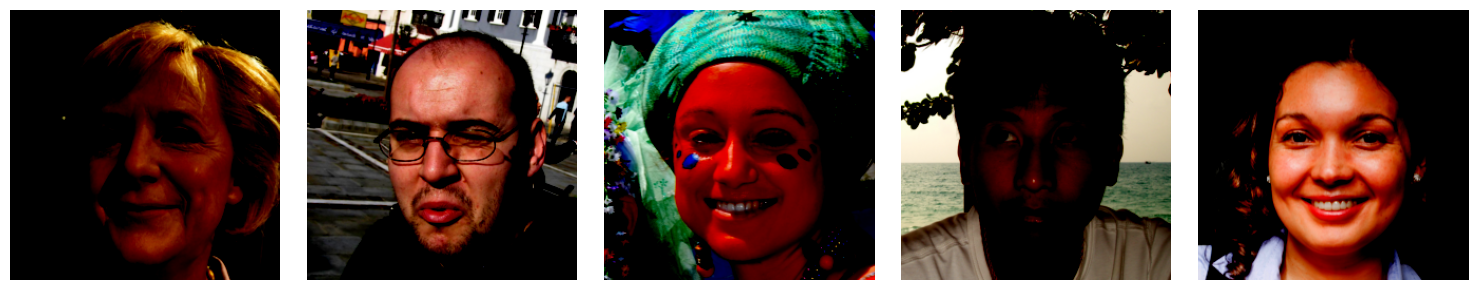

In [5]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))  # 1 row, 5 columns

for i, ax in enumerate(axs):
    img_np = images[i].permute(1, 2, 0).cpu().numpy()
    ax.imshow(img_np)       
    ax.axis('off')             

plt.tight_layout()
plt.show()

In [6]:
from torchvision.utils import save_image
import PIL
def visualize_grid(images, target='image.png', nrow=10, figsize=None, normalize=True):
    # Save images.
    save_grid(images, target, nrow=nrow, normalize=normalize)
    visualize_pil(target, figsize=figsize)


def save_grid(images, target='image.png', nrow=10, normalize=True):
    # Save images.
    if normalize:
        images = norm_image_01(images)
    save_image(images, target, nrow=nrow)

def norm_image_01(x):
    return (x * 0.5 + 0.5).clip(0, 1)

def visualize_pil(target, figsize=None):
    pil_image = PIL.Image.open(target)
    if figsize is None:
        plt.figure(figsize=(24, 24))
    else:
        plt.figure(figsize=figsize)
    plt.imshow(pil_image)
    plt.axis('off')  # Turn off axis numbers and ticks
    plt.show()




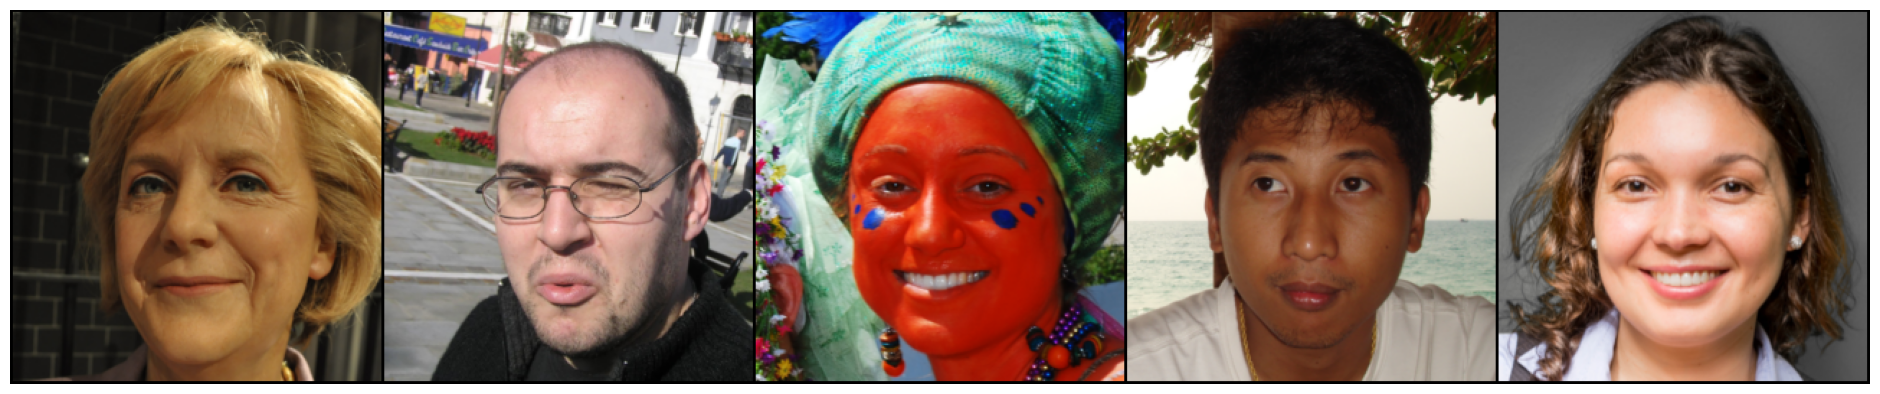

In [7]:
visualize_grid(images, nrow=10)

In [8]:
#To check how odeint works
from torchdiffeq import odeint
def f(t,x):
    return t
time_step = torch.tensor([0.0, 5.0])
x0 = torch.tensor(0, dtype=torch.float32)
x_T = odeint(f,x0,  time_step)
x_T


tensor([ 0.0000, 12.5000])

In [9]:
img1 = images[0]
img1.shape
(5, *img1.shape)


(5, 3, 256, 256)

In [10]:
#To check if pfode.py is working
from main.pfode import PFODE
pf_ode = PFODE(edmsampler1, model, (5, *img1.shape))
x_T = pf_ode.gaussian_prior_x_T(5)
x_0 = pf_ode.solve(x_T)

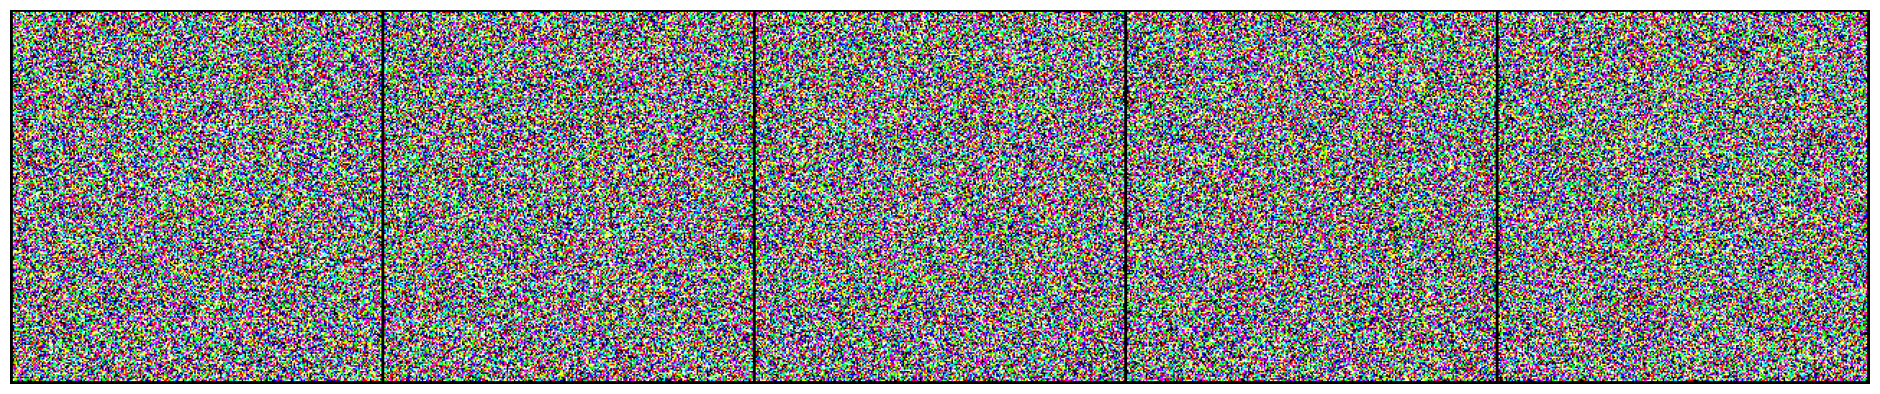

In [11]:
visualize_grid(x_T, nrow=5)

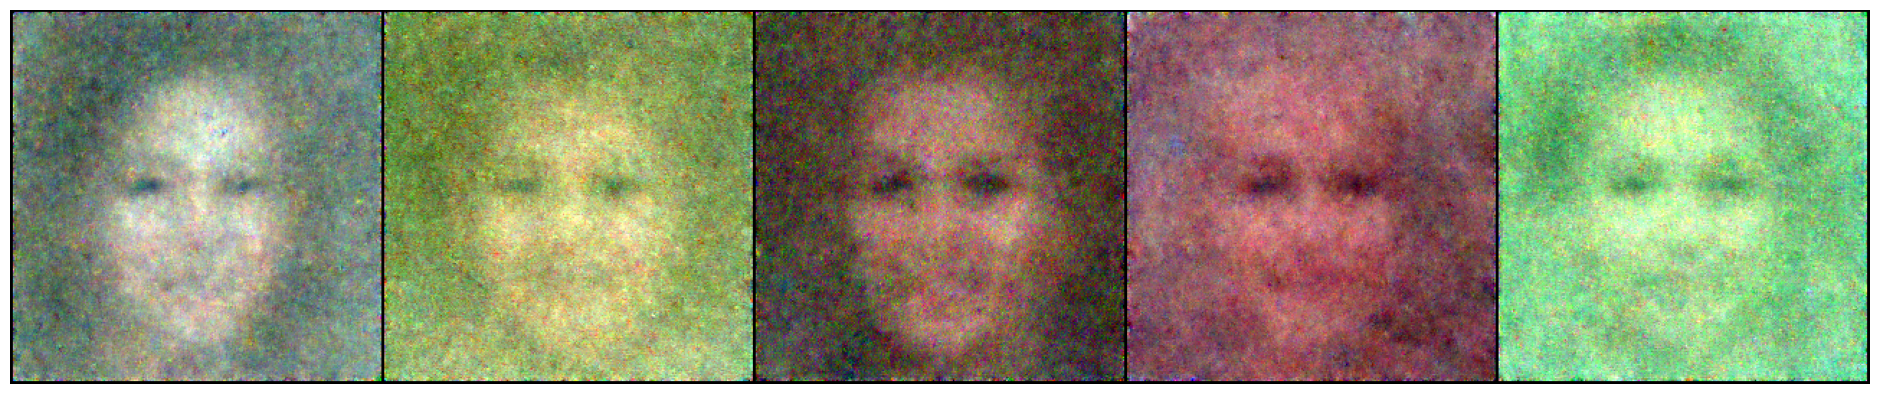

In [12]:
visualize_grid(x_0, nrow=5)